
# Testing whether observed productivity is Markov-sufficient

This notebook runs four linked tests:

1. **Held-out prediction:** does earlier history improve prediction after conditioning on career age, current productivity, and activity status?
2. **Same present, different past:** among researchers at the same age and current productivity, do risers and fallers have different futures?
3. **Chapman–Kolmogorov:** do observed multi-year rank transitions equal products of one-year rank transitions?
4. **Flexible Markov simulation:** can a nonparametric first-order transition kernel reproduce empirical rank mixing, and which history variables repair it?

The loading step matches `prepare.ipynb`: it uses `CareerAgeZero`, retains trajectories observed through year 20, pivots to years 0–20, and fills omitted person-years with zero. Set `REQUIRE_ALL_YEARS = True` to restrict the analysis to IDs with all 21 rows explicitly present.


In [1]:

# Cell 1: imports and configuration

from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from scipy.spatial import cKDTree
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import make_pipeline

SEED = 17
EPS = 0.49
Y = 20

ID_COL = "dblp_id"
YEAR_COL = "CareerAgeZero"
Q_COL = "pubs_adj"

REQUIRE_ALL_YEARS = False
FAST_MODE = os.environ.get("SPAARW_FAST", "1") == "1"

N_SPLITS = 3 if FAST_MODE else 5
N_BOOT = 50 if FAST_MODE else 500
N_NULL = 50 if FAST_MODE else 300
N_REPS = 3 if FAST_MODE else 100
MODEL_TREES = 60 if FAST_MODE else 300
K_NEIGHBORS = 30 if FAST_MODE else 75

def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / ".git").exists():
            return candidate
        if (candidate / "prepare").exists() and (candidate / "plot").exists():
            return candidate
    return Path.cwd()

PROJ_ROOT = find_project_root()

def find_data_path():
    env_path = os.environ.get("SPAARW_DATA")
    if env_path:
        path = Path(env_path).expanduser()
        if not path.exists():
            raise FileNotFoundError(f"SPAARW_DATA does not exist: {path}")
        return path

    candidates = [
        PROJ_ROOT / "prepare" / "output" / "df_traj_all.csv",
        PROJ_ROOT / "prepare" / "output" / "all-trajectories.csv",
        PROJ_ROOT / "import" / "input" / "df_traj_all.csv",
        PROJ_ROOT / "import" / "input" / "all-trajectories.csv",
        Path.cwd() / "df_traj_all.csv",
        Path.cwd().parent / "output" / "df_traj_all.csv"
    ]

    for path in candidates:
        if path.exists():
            return path

    matches = [
        path for path in PROJ_ROOT.rglob("df_traj_all.csv")
        if ".git" not in path.parts
    ]
    if matches:
        return matches[0]

    raise FileNotFoundError(
        "Could not locate df_traj_all.csv. Set the SPAARW_DATA environment "
        "variable or edit DATA_PATH in this cell."
    )

DATA_PATH = find_data_path()

OUT_DIR = PROJ_ROOT / "plot" / "output" / "markov_sufficiency"
RESULT_DIR = PROJ_ROOT / "fit" / "output" / "markov_sufficiency"
OUT_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJ_ROOT}")
print(f"Data: {DATA_PATH}")
print(f"Fast mode: {FAST_MODE}")


Project root: /Users/samlunemagid/Desktop/SPAARW2
Data: /Users/samlunemagid/Desktop/SPAARW2/prepare/output/df_traj_all.csv
Fast mode: True


In [2]:

# Cell 2: load trajectories using the prepare-notebook convention

if DATA_PATH.suffix.lower() == ".parquet":
    raw = pd.read_parquet(DATA_PATH)
else:
    raw = pd.read_csv(DATA_PATH)

if YEAR_COL not in raw.columns:
    if "CareerAge" not in raw.columns:
        raise KeyError("The input needs CareerAgeZero or CareerAge.")

    career_age = pd.to_numeric(raw["CareerAge"], errors="coerce")
    if career_age.min() >= 1 and career_age.max() >= Y + 1:
        raw[YEAR_COL] = career_age - 1
    else:
        raw[YEAR_COL] = career_age

required = [ID_COL, YEAR_COL, Q_COL]
missing = [column for column in required if column not in raw.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

df = raw[required].copy()
df[YEAR_COL] = pd.to_numeric(df[YEAR_COL], errors="coerce")
df[Q_COL] = pd.to_numeric(df[Q_COL], errors="coerce")
df = df.dropna(subset=required)
df = df[df[YEAR_COL].between(0, Y)].copy()
df[YEAR_COL] = df[YEAR_COL].astype(int)
df[Q_COL] = df[Q_COL].clip(lower=0)

if df.duplicated([ID_COL, YEAR_COL]).any():
    df = df.groupby([ID_COL, YEAR_COL], as_index=False)[Q_COL].sum()

coverage = (
    df.groupby(ID_COL)[YEAR_COL]
    .agg(["min", "max", "nunique"])
)

reaches_year_20 = coverage["max"].eq(Y)
strictly_complete = (
    coverage["min"].eq(0)
    & coverage["max"].eq(Y)
    & coverage["nunique"].eq(Y + 1)
)

eligible_ids = coverage.index[
    strictly_complete if REQUIRE_ALL_YEARS else reaches_year_20
]

analysis_df = df[df[ID_COL].isin(eligible_ids)].copy()
q_panel = (
    analysis_df.pivot(index=ID_COL, columns=YEAR_COL, values=Q_COL)
    .reindex(columns=np.arange(Y + 1))
    .fillna(0.0)
    .sort_index()
)

if q_panel.empty:
    raise ValueError(
        "No eligible trajectories. Check YEAR_COL and the trajectory-selection rule."
    )

Q = q_panel.to_numpy(dtype=float)
IDS = q_panel.index.to_numpy()

missing_person_years = int(q_panel.size - len(analysis_df))

print(f"IDs observed through year 20: {int(reaches_year_20.sum()):,}")
print(f"IDs with all 21 rows present: {int(strictly_complete.sum()):,}")
print(f"Trajectories used: {Q.shape[0]:,}")
print(f"Missing person-years filled with zero: {missing_person_years:,}")
print(f"Panel shape: {Q.shape}")


IDs observed through year 20: 591
IDs with all 21 rows present: 510
Trajectories used: 591
Missing person-years filled with zero: 315
Panel shape: (591, 21)


In [3]:

# Cell 3: history features and future targets

def run_lengths(active):
    active = np.asarray(active, dtype=bool)
    active_run = np.zeros(active.size, dtype=int)
    zero_run = np.zeros(active.size, dtype=int)

    a = z = 0
    for j, value in enumerate(active):
        a = a + 1 if value else 0
        z = z + 1 if not value else 0
        active_run[j] = a
        zero_run[j] = z

    return active_run, zero_run


def build_long_features(q_panel, eps=EPS, horizons=(1, 2, 5)):
    parts = []

    for scholar_id, row in q_panel.iterrows():
        q = row.to_numpy(dtype=float)
        z = np.log(q + eps)
        active = q > 0
        active_run, zero_run = run_lengths(active)

        part = pd.DataFrame({
            ID_COL: scholar_id,
            YEAR_COL: np.arange(q.size),
            "q": q,
            "z": z,
            "active": active.astype(int),
            "dz1": np.r_[np.nan, np.diff(z)],
            "slope3": np.r_[np.nan, np.nan, (z[2:] - z[:-2]) / 2],
            "sd3": pd.Series(z).rolling(3, min_periods=2).std(ddof=0).to_numpy(),
            "cum_q": np.cumsum(q),
            "prior_max": np.maximum.accumulate(q),
            "active_run": active_run,
            "zero_run": zero_run
        })
        parts.append(part)

    out = pd.concat(parts, ignore_index=True)
    out["drawdown"] = np.log1p(out["prior_max"]) - np.log1p(out["q"])
    out["log_cum_q"] = np.log1p(out["cum_q"])
    out["rank_pct"] = out.groupby(YEAR_COL)["q"].rank(method="average", pct=True)
    out["prev_rank_pct"] = out.groupby(ID_COL)["rank_pct"].shift(1)

    grouped = out.groupby(ID_COL, sort=False)
    for h in horizons:
        out[f"z_f{h}"] = grouped["z"].shift(-h)
        out[f"q_f{h}"] = grouped["q"].shift(-h)
        out[f"rank_f{h}"] = grouped["rank_pct"].shift(-h)
        out[f"rank_shift_f{h}"] = out[f"rank_f{h}"] - out["rank_pct"]

    out["direction"] = np.select(
        [out["dz1"] > 0, out["dz1"] < 0],
        ["riser", "faller"],
        default="flat"
    )

    return out


long = build_long_features(q_panel)
long.head()


,dblp_id,CareerAgeZero,q,z,active,dz1,slope3,sd3,cum_q,prior_max,...,rank_shift_f1,z_f2,q_f2,rank_f2,rank_shift_f2,z_f5,q_f5,rank_f5,rank_shift_f5,direction
0,=Ouml=zsu:M=_Tamer1983.0,0,7.200019,2.039923,1,NaN,NaN,NaN,7.200019,7.200019,...,-0.349408,1.313472,3.229064,0.402707,-0.410321,2.664629,13.872618,0.854484,0.041455,flat
1,=Ouml=zsu:M=_Tamer1983.0,1,3.406681,1.360125,1,-0.679798,NaN,0.339899,10.606700,7.200019,...,-0.060914,-0.713350,0.000000,0.093063,-0.370558,2.618421,13.224046,0.851100,0.387479,faller
2,=Ouml=zsu:M=_Tamer1983.0,2,3.229064,1.313472,1,-0.046653,-0.363226,0.332003,13.835764,7.200019,...,-0.309645,1.225058,2.914364,0.317259,-0.085448,1.711721,5.048483,0.489848,0.087140,faller
3,=Ouml=zsu:M=_Tamer1983.0,3,0.000000,-0.713350,0,-2.026822,-1.036738,0.966637,13.835764,7.200019,...,0.224196,2.664629,13.872618,0.854484,0.761421,2.854958,16.883716,0.919628,0.826565,faller
4,=Ouml=zsu:M=_Tamer1983.0,4,2.914364,1.225058,1,1.938408,-0.044207,0.935310,16.750128,7.200019,...,0.537225,2.618421,13.224046,0.851100,0.533841,1.630104,4.614405,0.460237,0.142978,riser



## A. Does history improve held-out prediction?

The baseline uses only:

\[
(t,\ z_t,\ \mathbf{1}\{q_t>0\}).
\]

The augmented model adds recent change, recent slope and volatility, cumulative output, distance below the prior maximum, and run lengths. Researchers—not rows—are held out. A positive `mae_gain` means that history improves prediction.


In [4]:

# Cell 4: grouped out-of-sample prediction test

BASE_FEATURES = [YEAR_COL, "z", "active"]
HISTORY_FEATURES = BASE_FEATURES + [
    "dz1", "slope3", "sd3", "log_cum_q",
    "drawdown", "active_run", "zero_run"
]


def prediction_model():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        ExtraTreesRegressor(
            n_estimators=MODEL_TREES,
            min_samples_leaf=10,
            max_features=1.0,
            n_jobs=1,
            random_state=SEED
        )
    )

def cluster_bootstrap_mae_gain(y, pred_base, pred_history, groups, n_boot=N_BOOT, seed=SEED):
    rng = np.random.default_rng(seed)
    unique = pd.unique(groups)
    by_group = {g: np.flatnonzero(groups == g) for g in unique}

    gain = np.mean(np.abs(y - pred_base)) - np.mean(np.abs(y - pred_history))
    draws = np.empty(n_boot)

    for b in range(n_boot):
        sampled = rng.choice(unique, size=unique.size, replace=True)
        idx = np.concatenate([by_group[g] for g in sampled])
        draws[b] = (
            np.mean(np.abs(y[idx] - pred_base[idx]))
            - np.mean(np.abs(y[idx] - pred_history[idx]))
        )

    return gain, np.quantile(draws, [0.025, 0.975])


def compare_predictors(data, target):
    use = data[BASE_FEATURES + HISTORY_FEATURES + [target, ID_COL]].dropna(subset=[target]).copy()
    use = use.loc[:, ~use.columns.duplicated()]

    y = use[target].to_numpy()
    groups = use[ID_COL].to_numpy()
    cv = GroupKFold(n_splits=N_SPLITS)

    pred_base = cross_val_predict(
        prediction_model(),
        use[BASE_FEATURES],
        y,
        groups=groups,
        cv=cv,
        n_jobs=1
    )

    pred_history = cross_val_predict(
        prediction_model(),
        use[HISTORY_FEATURES],
        y,
        groups=groups,
        cv=cv,
        n_jobs=1
    )

    gain, ci = cluster_bootstrap_mae_gain(
        y, pred_base, pred_history, groups
    )

    return {
        "target": target,
        "n": len(use),
        "mae_base": np.mean(np.abs(y - pred_base)),
        "mae_history": np.mean(np.abs(y - pred_history)),
        "mae_gain": gain,
        "gain_ci_low": ci[0],
        "gain_ci_high": ci[1],
        "rho_base": spearmanr(y, pred_base).statistic,
        "rho_history": spearmanr(y, pred_history).statistic
    }


prediction_results = pd.DataFrame([
    compare_predictors(long, f"{kind}_f{h}")
    for kind in ["z", "rank"]
    for h in [1, 2, 5]
])

prediction_results.to_csv(
    RESULT_DIR / "history_predictive_gain.csv",
    index=False
)

prediction_results


,target,n,mae_base,mae_history,mae_gain,gain_ci_low,gain_ci_high,rho_base,rho_history
0,z_f1,11820,0.748053,0.685589,0.062464,0.055452,0.070403,0.616514,0.681227
1,z_f2,11229,0.758963,0.705651,0.053312,0.045306,0.061100,0.591948,0.648989
2,z_f5,9456,0.803930,0.757391,0.046539,0.037721,0.053349,0.496146,0.561007
3,rank_f1,11820,0.184243,0.168231,0.016012,0.013978,0.018227,0.615696,0.681128
4,rank_f2,11229,0.188880,0.175548,0.013333,0.011499,0.015080,0.591496,0.652501
5,rank_f5,9456,0.207258,0.195602,0.011656,0.009554,0.013593,0.490992,0.556517



Interpretation:

- `gain_ci_low > 0`: earlier history improves held-out prediction beyond the current observed state.
- A gain only at longer horizons is especially relevant to rank mixing.
- This rejects state sufficiency, not necessarily all Markov structure: the process may be Markov in a richer latent state.



## B. Same present, different past

Researchers are stratified by career age, activity status, and a narrow current-productivity bin. Within those strata, the code compares the future percentile ranks of researchers currently rising versus currently falling.


In [5]:

# Cell 5: matched riser-faller contrasts

def add_current_bins(data, n_bins=15):
    out = data.copy()

    def qbin(series):
        return pd.qcut(
            series.rank(method="first"),
            q=min(n_bins, series.notna().sum()),
            labels=False,
            duplicates="drop"
        )

    out["current_bin"] = out.groupby(YEAR_COL)["z"].transform(qbin)
    return out


def matched_arrays(data, outcome):
    use = data[
        data["direction"].isin(["riser", "faller"])
    ].dropna(subset=[outcome, "current_bin"]).copy()

    stratum_index = pd.MultiIndex.from_frame(
        use[[YEAR_COL, "active", "current_bin"]]
    )
    stratum = pd.factorize(stratum_index)[0]
    direction = use["direction"].eq("riser").astype(int).to_numpy()
    scholar, scholar_ids = pd.factorize(use[ID_COL])
    y = use[outcome].to_numpy(dtype=float)

    n_strata = stratum.max() + 1
    cell = 2 * stratum + direction
    counts = np.bincount(cell, minlength=2 * n_strata).reshape(n_strata, 2)
    keep_stratum = (counts[:, 0] >= 3) & (counts[:, 1] >= 3)
    keep = keep_stratum[stratum]

    return {
        "stratum": stratum[keep],
        "direction": direction[keep],
        "scholar": scholar[keep],
        "y": y[keep],
        "n_strata": n_strata,
        "n_scholars": len(scholar_ids)
    }


def weighted_stratified_difference(arrays, scholar_weights):
    row_weights = scholar_weights[arrays["scholar"]]
    cell = 2 * arrays["stratum"] + arrays["direction"]
    shape = (arrays["n_strata"], 2)

    count = np.bincount(
        cell,
        weights=row_weights,
        minlength=2 * arrays["n_strata"]
    ).reshape(shape)
    total = np.bincount(
        cell,
        weights=row_weights * arrays["y"],
        minlength=2 * arrays["n_strata"]
    ).reshape(shape)

    valid = (count[:, 0] > 0) & (count[:, 1] > 0)
    means = np.divide(total, count, out=np.full_like(total, np.nan), where=count > 0)
    diff = means[:, 1] - means[:, 0]
    weight = np.divide(
        2 * count[:, 0] * count[:, 1],
        count[:, 0] + count[:, 1],
        out=np.zeros(count.shape[0]),
        where=(count[:, 0] + count[:, 1]) > 0
    )

    return np.average(diff[valid], weights=weight[valid])


def cluster_bootstrap_matched_difference(data, outcome, n_boot=N_BOOT, seed=SEED):
    rng = np.random.default_rng(seed)
    arrays = matched_arrays(data, outcome)
    base_weights = np.ones(arrays["n_scholars"], dtype=float)
    observed = weighted_stratified_difference(arrays, base_weights)
    draws = np.empty(n_boot)

    probabilities = np.full(arrays["n_scholars"], 1 / arrays["n_scholars"])
    for b in range(n_boot):
        scholar_weights = rng.multinomial(arrays["n_scholars"], probabilities)
        draws[b] = weighted_stratified_difference(arrays, scholar_weights)

    valid = draws[np.isfinite(draws)]
    return observed, np.quantile(valid, [0.025, 0.975])


matched = add_current_bins(long, n_bins=15)

same_present_results = []
for h in [1, 2, 5]:
    effect, ci = cluster_bootstrap_matched_difference(
        matched,
        f"rank_f{h}"
    )

    same_present_results.append({
        "horizon": h,
        "riser_minus_faller_future_rank": effect,
        "ci_low": ci[0],
        "ci_high": ci[1]
    })

same_present_results = pd.DataFrame(same_present_results)
same_present_results.to_csv(
    RESULT_DIR / "same_present_different_past.csv",
    index=False
)

same_present_results


,horizon,riser_minus_faller_future_rank,ci_low,ci_high
0,1,-0.122762,-0.132030,-0.114891
1,2,-0.108085,-0.118252,-0.099306
2,5,-0.095875,-0.107391,-0.084271



A confidence interval excluding zero means that two researchers with approximately the same present state have different futures depending on how they arrived there. That is direct evidence that current productivity is not a sufficient state.



## C. Chapman–Kolmogorov test for rank transitions

For a first-order, age-varying Markov process,

\[
P(R_{t+h}\mid R_t)
=
P_t P_{t+1}\cdots P_{t+h-1}.
\]

The empirical direct transition is compared with this matrix product. A parametric bootstrap from the fitted age-specific Markov chain supplies the finite-sample null distribution.


In [6]:

# Cell 6: Chapman-Kolmogorov rank test

def rank_state_panel(q, n_states):
    n, years = q.shape
    states = np.zeros((n, years), dtype=int)

    for t in range(years):
        ranks = pd.Series(q[:, t]).rank(method="average", pct=True).to_numpy()
        states[:, t] = np.minimum(
            np.floor(ranks * n_states).astype(int),
            n_states - 1
        )

    return states


def transition_matrix(states, t0, t1, n_states, alpha=0.5):
    counts = np.full((n_states, n_states), alpha, dtype=float)
    np.add.at(counts, (states[:, t0], states[:, t1]), 1)
    return counts / counts.sum(axis=1, keepdims=True)


def one_step_matrices(states, n_states):
    return [
        transition_matrix(states, t, t + 1, n_states)
        for t in range(states.shape[1] - 1)
    ]


def ck_error(states, horizon, n_states):
    one_step = one_step_matrices(states, n_states)
    errors = []

    for t in range(states.shape[1] - horizon):
        direct = transition_matrix(states, t, t + horizon, n_states)
        composed = np.eye(n_states)

        for j in range(t, t + horizon):
            composed = composed @ one_step[j]

        origin_weight = np.bincount(
            states[:, t],
            minlength=n_states
        ).astype(float)
        origin_weight /= origin_weight.sum()

        row_tv = 0.5 * np.abs(direct - composed).sum(axis=1)
        errors.append(np.sum(origin_weight * row_tv))

    return np.mean(errors)


def simulate_markov_chain(one_step, initial_states, rng):
    n = len(initial_states)
    years = len(one_step) + 1
    sim = np.zeros((n, years), dtype=int)
    sim[:, 0] = rng.choice(initial_states, size=n, replace=True)

    for t, matrix in enumerate(one_step):
        u = rng.random(n)
        cumulative = np.cumsum(matrix[sim[:, t]], axis=1)
        sim[:, t + 1] = (u[:, None] > cumulative).sum(axis=1)

    return sim


def ck_parametric_bootstrap(q, n_states, horizon, n_null=N_NULL, seed=SEED):
    rng = np.random.default_rng(seed)
    states = rank_state_panel(q, n_states)
    one_step = one_step_matrices(states, n_states)
    observed = ck_error(states, horizon, n_states)

    null = np.empty(n_null)
    for b in range(n_null):
        sim = simulate_markov_chain(
            one_step,
            states[:, 0],
            rng
        )
        null[b] = ck_error(sim, horizon, n_states)

    p = (1 + np.sum(null >= observed)) / (n_null + 1)

    return {
        "rank_states": n_states,
        "horizon": horizon,
        "observed_error": observed,
        "null_mean": null.mean(),
        "null_95": np.quantile(null, 0.95),
        "p_value": p
    }


ck_results = pd.DataFrame([
    ck_parametric_bootstrap(Q, n_states, horizon)
    for n_states in [5, 10, 20]
    for horizon in [2, 3, 5]
])

ck_results.to_csv(
    RESULT_DIR / "chapman_kolmogorov_rank_test.csv",
    index=False
)

ck_results


,rank_states,horizon,observed_error,null_mean,null_95,p_value
0,5,2,0.129803,0.056542,0.059485,0.019608
1,5,3,0.159554,0.061257,0.066101,0.019608
2,5,5,0.178985,0.063932,0.068393,0.019608
3,10,2,0.172828,0.118509,0.122596,0.019608
4,10,3,0.204980,0.127999,0.132374,0.019608
5,10,5,0.228803,0.130014,0.135456,0.019608
6,20,2,0.246369,0.201403,0.203897,0.019608
7,20,3,0.281230,0.214323,0.217630,0.019608
8,20,5,0.302593,0.215047,0.218235,0.019608



Interpret the Chapman–Kolmogorov result cautiously:

- A small \(p\)-value rejects first-order Markov behavior in the chosen rank-state representation.
- Repeat across 5, 10, and 20 states because coarse discretization can create apparent memory.
- Agreement here does not prove productivity itself is Markov; it only means this particular rank-transition restriction is not rejected.



## D. Flexible nonparametric Markov null

The following simulator resamples empirical next-year outcomes from nearest neighbors with the same career age and activity state.

The baseline conditions only on current log productivity. The alternatives add selected history summaries. Because no Gaussian, Laplace, linear-AR, hurdle, or restart form is imposed, failure of the baseline is much stronger evidence than failure of a parametric AR model.


In [7]:

# Cell 7: state summaries for empirical and simulated prefixes

def state_feature_matrix(trj, t, names):
    q = trj[:, :t + 1]
    z = np.log(q + EPS)
    n = q.shape[0]
    features = [z[:, -1]]

    for name in names:
        if name == "dz1":
            value = z[:, -1] - z[:, -2] if t >= 1 else np.zeros(n)

        elif name == "slope3":
            value = (z[:, -1] - z[:, -3]) / 2 if t >= 2 else np.zeros(n)

        elif name == "sd3":
            value = np.std(z[:, max(0, t - 2):t + 1], axis=1)

        elif name == "log_cum_q":
            value = np.log1p(q.sum(axis=1))

        elif name == "drawdown":
            value = np.log1p(q.max(axis=1)) - np.log1p(q[:, -1])

        elif name == "active_run":
            value = np.zeros(n)
            active = q > 0
            for i in range(n):
                run = 0
                for flag in active[i, ::-1]:
                    if flag:
                        run += 1
                    else:
                        break
                value[i] = run

        elif name == "zero_run":
            value = np.zeros(n)
            active = q > 0
            for i in range(n):
                run = 0
                for flag in active[i, ::-1]:
                    if not flag:
                        run += 1
                    else:
                        break
                value[i] = run

        else:
            raise ValueError(f"Unknown state feature: {name}")

        features.append(value)

    return np.column_stack(features)


STATE_SETS = {
    "Markov: q_t only": [],
    "+ recent increment": ["dz1"],
    "+ slope and volatility": ["slope3", "sd3"],
    "+ cumulative history": ["log_cum_q", "drawdown"],
    "+ all history": [
        "dz1", "slope3", "sd3", "log_cum_q",
        "drawdown", "active_run", "zero_run"
    ]
}


In [8]:

# Cell 8: fit age- and activity-specific nearest-neighbor transition kernels

def fit_knn_kernels(empirical_q, feature_names, k=K_NEIGHBORS):
    kernels = {}

    for t in range(empirical_q.shape[1] - 1):
        X = state_feature_matrix(empirical_q, t, feature_names)
        y = empirical_q[:, t + 1]
        active = empirical_q[:, t] > 0

        for state in [0, 1]:
            idx = np.flatnonzero(active == state)
            Xs = X[idx]
            ys = y[idx]

            center = np.nanmedian(Xs, axis=0)
            scale = np.nanstd(Xs, axis=0)
            scale[~np.isfinite(scale) | (scale == 0)] = 1

            Xs = np.where(np.isfinite(Xs), Xs, center)
            Xs = (Xs - center) / scale

            n_neighbors = min(k, len(idx))
            kernels[(t, state)] = {
                "tree": cKDTree(Xs),
                "next_q": ys,
                "center": center,
                "scale": scale,
                "n_neighbors": n_neighbors
            }

    return kernels


def simulate_knn_kernel(empirical_q, kernels, feature_names, n_sim, rng):
    years = empirical_q.shape[1]
    sim = np.zeros((n_sim, years), dtype=float)
    sim[:, 0] = rng.choice(empirical_q[:, 0], size=n_sim, replace=True)

    for t in range(years - 1):
        X = state_feature_matrix(sim, t, feature_names)
        active = sim[:, t] > 0

        for state in [0, 1]:
            rows = np.flatnonzero(active == state)
            if not len(rows):
                continue

            kernel = kernels[(t, state)]
            Xs = X[rows]
            Xs = np.where(np.isfinite(Xs), Xs, kernel["center"])
            Xs = (Xs - kernel["center"]) / kernel["scale"]

            _, neighbors = kernel["tree"].query(
                Xs,
                k=kernel["n_neighbors"],
                workers=1
            )
            if neighbors.ndim == 1:
                neighbors = neighbors[:, None]

            choice = rng.integers(0, neighbors.shape[1], size=len(rows))
            selected = neighbors[np.arange(len(rows)), choice]
            sim[rows, t + 1] = kernel["next_q"][selected]

    return sim


In [9]:

# Cell 9: rank-mixing diagnostics

def percentile_ranks(values):
    return pd.Series(values).rank(method="average", pct=True).to_numpy()


def rank_mixing_curves(q):
    years = q.shape[1]
    ranks = np.column_stack([
        percentile_ranks(q[:, t])
        for t in range(years)
    ])

    corr = np.array([
        spearmanr(ranks[:, 0], ranks[:, t]).statistic
        for t in range(years)
    ])

    displacement = np.mean(
        np.abs(ranks - ranks[:, [0]]),
        axis=0
    )

    return corr, displacement


emp_corr, emp_disp = rank_mixing_curves(Q)

simulation_rows = []
curve_store = {}

for label, feature_names in STATE_SETS.items():
    print(f"Fitting {label}")
    kernels = fit_knn_kernels(Q, feature_names)

    corr_draws = np.empty((N_REPS, Y + 1))
    disp_draws = np.empty((N_REPS, Y + 1))

    for rep in range(N_REPS):
        rng = np.random.default_rng(SEED + 1000 * len(curve_store) + rep)
        sim = simulate_knn_kernel(
            Q,
            kernels,
            feature_names,
            n_sim=Q.shape[0],
            rng=rng
        )
        corr_draws[rep], disp_draws[rep] = rank_mixing_curves(sim)

    curve_store[label] = {
        "corr_mean": corr_draws.mean(axis=0),
        "corr_low": np.quantile(corr_draws, 0.025, axis=0),
        "corr_high": np.quantile(corr_draws, 0.975, axis=0),
        "disp_mean": disp_draws.mean(axis=0),
        "disp_low": np.quantile(disp_draws, 0.025, axis=0),
        "disp_high": np.quantile(disp_draws, 0.975, axis=0)
    }

    simulation_rows.append({
        "model": label,
        "rank_corr_rmse": np.sqrt(
            np.mean((corr_draws.mean(axis=0) - emp_corr) ** 2)
        ),
        "rank_displacement_rmse": np.sqrt(
            np.mean((disp_draws.mean(axis=0) - emp_disp) ** 2)
        ),
        "terminal_corr_empirical": emp_corr[-1],
        "terminal_corr_simulated": corr_draws[:, -1].mean(),
        "terminal_displacement_empirical": emp_disp[-1],
        "terminal_displacement_simulated": disp_draws[:, -1].mean()
    })

kernel_results = pd.DataFrame(simulation_rows).sort_values("rank_corr_rmse")
kernel_results.to_csv(
    RESULT_DIR / "knn_markov_rank_mixing.csv",
    index=False
)

kernel_results


Fitting Markov: q_t only
Fitting + recent increment
Fitting + slope and volatility
Fitting + cumulative history
Fitting + all history


,model,rank_corr_rmse,rank_displacement_rmse,terminal_corr_empirical,terminal_corr_simulated,terminal_displacement_empirical,terminal_displacement_simulated
3,+ cumulative history,0.044506,0.011013,0.201571,0.252429,0.28871,0.276571
4,+ all history,0.051855,0.012024,0.201571,0.172258,0.28871,0.295227
1,+ recent increment,0.189052,0.039465,0.201571,0.032163,0.28871,0.323084
2,+ slope and volatility,0.197690,0.041928,0.201571,-0.017046,0.28871,0.333204
0,Markov: q_t only,0.261743,0.054837,0.201571,0.019880,0.28871,0.321922


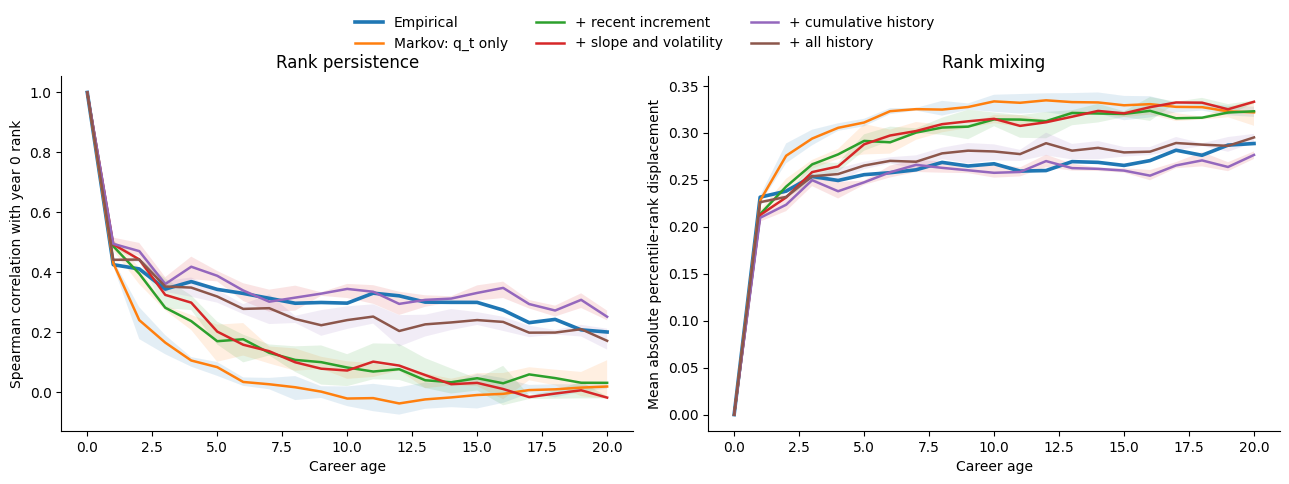

In [10]:

# Cell 10: plot rank persistence and rank displacement

years = np.arange(Y + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(
    years,
    emp_corr,
    linewidth=2.6,
    label="Empirical"
)

for label, values in curve_store.items():
    axes[0].plot(
        years,
        values["corr_mean"],
        linewidth=1.8,
        label=label
    )
    axes[0].fill_between(
        years,
        values["corr_low"],
        values["corr_high"],
        alpha=0.12
    )

axes[0].set(
    xlabel="Career age",
    ylabel="Spearman correlation with year 0 rank",
    title="Rank persistence"
)

axes[1].plot(
    years,
    emp_disp,
    linewidth=2.6,
    label="Empirical"
)

for label, values in curve_store.items():
    axes[1].plot(
        years,
        values["disp_mean"],
        linewidth=1.8,
        label=label
    )
    axes[1].fill_between(
        years,
        values["disp_low"],
        values["disp_high"],
        alpha=0.12
    )

axes[1].set(
    xlabel="Career age",
    ylabel="Mean absolute percentile-rank displacement",
    title="Rank mixing"
)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=3,
    frameon=False
)

fig.tight_layout()
fig.savefig(
    OUT_DIR / "knn_markov_rank_mixing.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



## Decision rule

The strongest evidence for moving beyond observed-state Markov models is the conjunction of:

1. history produces positive held-out predictive gain with a confidence interval above zero;
2. matched risers and fallers have different future ranks;
3. Chapman–Kolmogorov errors exceed their fitted-Markov null distribution;
4. the flexible \(q_t\)-only kernel reproduces one-step behavior but fails multi-year rank mixing;
5. one or more history-augmented kernels materially reduce rank-mixing error.

The winning history summary indicates the next model:

- `dz1` or `slope3` → latent momentum/local trend;
- `sd3` → persistent stochastic volatility;
- `log_cum_q` or `drawdown` → cumulative advantage/path dependence;
- run lengths → semi-Markov or explicit-duration states;
- broad gains from all history but no compact winner → hierarchical random persistence/volatility, followed by a latent-state model.
